# Fairness Metrics: Scholarship Qualification and Grants

This notebook compares all applicants, remote applicants, and center applicants using one qualification formula. The proxy score is `(3 * R-score + 0.5 * income-need score + 0.5 * work-hours score) / 4`; the top 40% of scores qualify (60th percentile cutoff).

Metrics: **qualified / all applicants in group**; **granted / qualified applicants**; and **granted / unqualified applicants**. These are separate rates with different denominators. The grant decision is the historical `decision_octroi` label.

Qualification cutoff: 0.5496
        % qualified / all  % granted / qualified  % granted / unqualified
group                                                                    
All                 40.00                  78.55                    14.20
remote              41.38                  61.09                     3.45
center              39.08                  90.87                    21.09


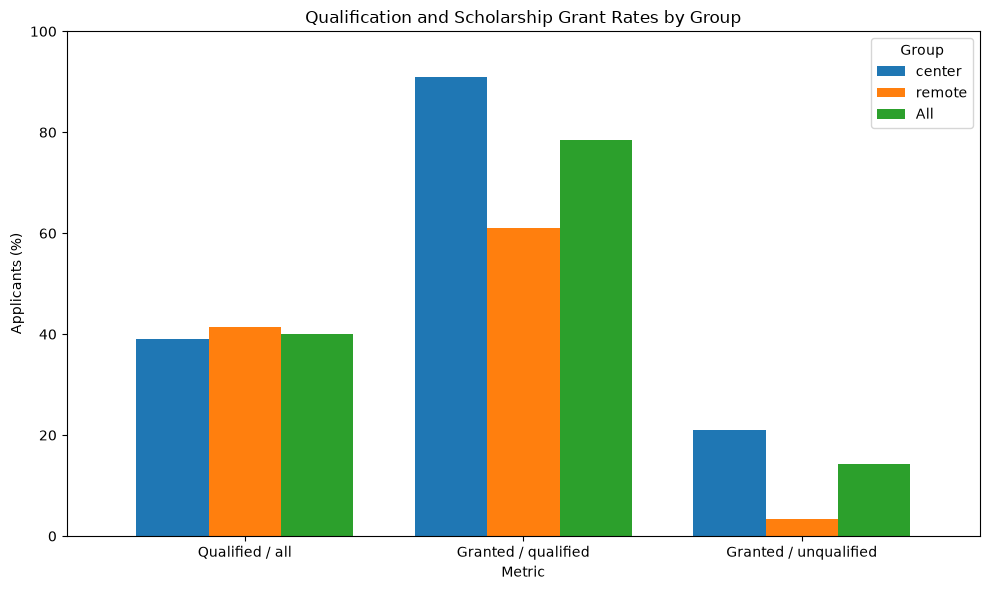

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/fairness_and_bias_analysis/past_committee_decisions/fairness_metrics.png


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

raw_relative_path = Path("equialgo-participants/data/donnees_demandes.csv")
repository_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / raw_relative_path).is_file()),
    None,
)
if repository_root is None:
    raise FileNotFoundError(f"Could not locate {raw_relative_path} from {Path.cwd()}")

analysis_dir = repository_root / "Analysis" / "fairness_and_bias_analysis" / "past_committee_decisions"
analysis_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(repository_root / raw_relative_path)

remote_regions = {"Bas-Saint-Laurent", "Cote-Nord", "Gaspesie-Iles-de-la-Madeleine"}
df["region_group"] = df["region_administrative"].apply(
    lambda region: "remote" if region in remote_regions else "center"
)

def minmax_scale(values):
    value_range = values.max() - values.min()
    if value_range == 0:
        return pd.Series(0.5, index=values.index)
    return (values - values.min()) / value_range

r_score = minmax_scale(df["cote_r_equivalent"])
income_need_score = 1 - minmax_scale(df["revenu_familial_estime"])
work_hours_score = minmax_scale(df["heures_travail_semaine"])
df["proxy_quality_score"] = (3 * r_score + 0.5 * income_need_score + 0.5 * work_hours_score) / 4
cutoff = df["proxy_quality_score"].quantile(0.60)
df["qualified_proxy"] = (df["proxy_quality_score"] >= cutoff).astype(int)

rows = []
for group_name in ["All", "remote", "center"]:
    group = df if group_name == "All" else df[df["region_group"] == group_name]
    qualified = group["qualified_proxy"] == 1
    unqualified = ~qualified
    rows.append(
        {
            "group": group_name,
            "% qualified / all": 100 * qualified.mean(),
            "% granted / qualified": 100 * group.loc[qualified, "decision_octroi"].mean(),
            "% granted / unqualified": 100 * group.loc[unqualified, "decision_octroi"].mean(),
        }
    )

table = pd.DataFrame(rows).set_index("group").round(2)
print(f"Qualification cutoff: {cutoff:.4f}")
print(table.to_string())

plot_data = table.T[["center", "remote", "All"]].rename(
    index={
        "% qualified / all": "Qualified / all",
        "% granted / qualified": "Granted / qualified",
        "% granted / unqualified": "Granted / unqualified",
    }
)
ax = plot_data.plot(kind="bar", figsize=(10, 6), width=0.78)
ax.set_title("Qualification and Scholarship Grant Rates by Group")
ax.set_xlabel("Metric")
ax.set_ylabel("Applicants (%)")
ax.set_ylim(0, 100)
ax.legend(title="Group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
chart_path = analysis_dir / "fairness_metrics.png"
ax.figure.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path}")

## Short analysis

About 4 in 10 applicants qualify in both groups: 41.38% remote and 39.08% center. But among qualified applicants, scholarships went to 61.09% of remote applicants and 90.87% of center applicants. Among applicants not qualified by the proxy, the rates were 3.45% remote and 21.09% center. These are past grant decisions compared with our estimated qualification rule; they do not tell us for certain who truly deserved a scholarship or why the difference occurred.

## Alternative formula: study-priority bonus

This scenario adds a `0.5` bonus for applicants in **Genie** or **Sante**. The weighted score is `(3.5 * R-score + 0.5 * income need + 0.5 * hours burden + 0.5 * study priority) / 5`. The cutoff is recalculated at the 60th percentile so approximately the top 40% qualify.

Study-bonus qualification cutoff: 0.5371
        % qualified / all  % granted / qualified  % granted / unqualified
group                                                                    
All                  40.0                  72.38                    18.32
remote               39.4                  57.04                     7.96
center               40.4                  82.34                    25.34


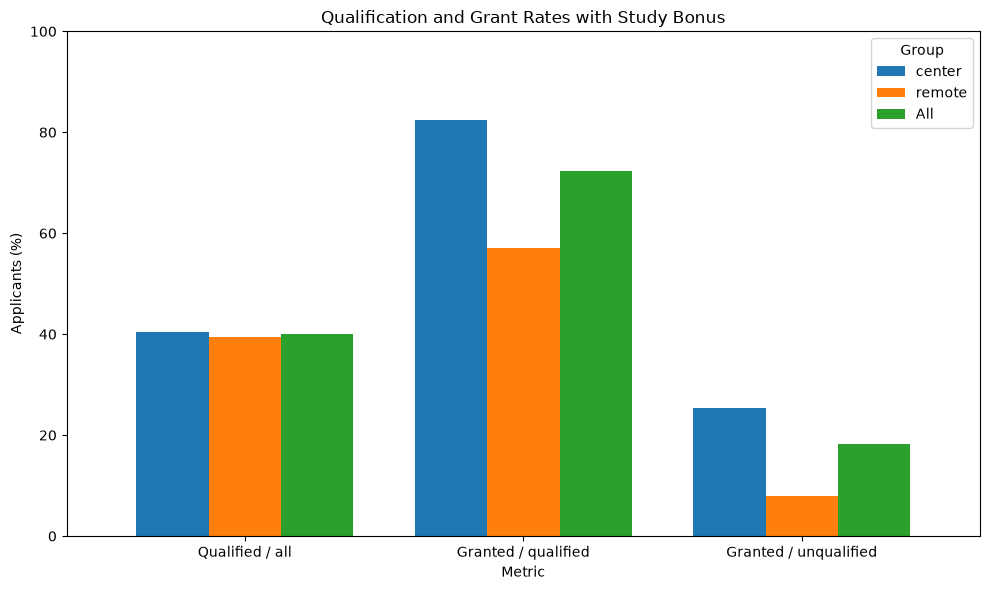

Saved chart: /Users/nawarturk/Desktop/1_Projects/polyml_hack/ivado/Analysis/fairness_and_bias_analysis/past_committee_decisions/fairness_metrics_with_study_bonus.png


In [2]:
study_priority = df["programme_etudes"].isin({"Genie", "Sante"}).astype(int)
df["proxy_score_with_study"] = (
    3.5 * r_score + 0.5 * income_need_score + 0.5 * work_hours_score + 0.5 * study_priority
) / 5
study_cutoff = df["proxy_score_with_study"].quantile(0.60)
df["qualified_with_study"] = (df["proxy_score_with_study"] >= study_cutoff).astype(int)

study_rows = []
for group_name in ["All", "remote", "center"]:
    group = df if group_name == "All" else df[df["region_group"] == group_name]
    qualified = group["qualified_with_study"] == 1
    unqualified = ~qualified
    study_rows.append(
        {
            "group": group_name,
            "% qualified / all": 100 * qualified.mean(),
            "% granted / qualified": 100 * group.loc[qualified, "decision_octroi"].mean(),
            "% granted / unqualified": 100 * group.loc[unqualified, "decision_octroi"].mean(),
        }
    )

study_table = pd.DataFrame(study_rows).set_index("group").round(2)
print(f"Study-bonus qualification cutoff: {study_cutoff:.4f}")
print(study_table.to_string())

study_plot_data = study_table.T[["center", "remote", "All"]].rename(
    index={
        "% qualified / all": "Qualified / all",
        "% granted / qualified": "Granted / qualified",
        "% granted / unqualified": "Granted / unqualified",
    }
)
ax = study_plot_data.plot(kind="bar", figsize=(10, 6), width=0.78)
ax.set_title("Qualification and Grant Rates with Study Bonus")
ax.set_xlabel("Metric")
ax.set_ylabel("Applicants (%)")
ax.set_ylim(0, 100)
ax.legend(title="Group")
ax.tick_params(axis="x", rotation=0)
ax.figure.tight_layout()
study_chart_path = analysis_dir / "fairness_metrics_with_study_bonus.png"
ax.figure.savefig(study_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart: {study_chart_path}")

### Short analysis

We changed the qualification formula by giving a bonus to applicants studying Genie or Sante. The revised rule qualifies nearly the same share in each group: 39.4% remote and 40.4% center. Even with this fairer qualification split, the bias pattern still appears in past grant decisions: 57.04% of qualified remote applicants received a scholarship, compared with 82.34% of qualified center applicants. This suggests that balancing who qualifies does not, by itself, remove the difference in historical grants. The proxy is only an estimate of qualification, so this comparison shows a pattern, not its cause.